# Finding/opening ACCESS-CM3 `cm3-run-11-08-2025-25km-beta-om3-new-um-params` test run output using intake

This notebook demonstrates how to using intake-esm to find and load data data from the ACCESS-CM3 `cm3-run-11-08-2025-25km-beta-om3-new-um-params` test run.

For more information about using intake-esm to find and load data, see:
- the [intake-esm documentation](https://intake-esm.readthedocs.io/en/stable/)
- [this section](https://access-nri-intake-catalog.readthedocs.io/en/latest/usage/quickstart.html#using-an-intake-esm-datastore) of the access-nri-intake-catalog documentation

In [2]:
#This cell must be in all notebooks!
#It allows us to run all the notebooks at once, note that the following cell has a tag "parameters" which allows us to pass in arguments externally using papermill (see mkfigs.sh for details)

#parameters

### USER EDIT start
#See the available cm3 experiment list here
#https://access-cm3-configs.readthedocs.io/Experiments/

#esm_file='/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/cm3-demo-datastore.json'
# esm_file='/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/cm3-virtual-datastore.json'

esm_file='/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-20-01-2026-om3-update/cm3-datastore/cm3-datastore.json'

dpi=300
### USER EDIT stop

import os
from matplotlib import rcParams
%matplotlib inline
rcParams['figure.dpi']= dpi

plotfolder=f"/g/data/{os.environ['PROJECT']}/{os.environ['USER']}/access-cm3-paper-figs/"
os.makedirs(plotfolder, exist_ok=True)

 # a similar cell under this means it's being run in batch
print("ESM datastore path: ",esm_file)
print("Plot folder path: ",plotfolder)

ESM datastore path:  /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-20-01-2026-om3-update/cm3-datastore/cm3-datastore.json
Plot folder path:  /g/data/tm70/cyb561/access-cm3-paper-figs/


### Note: In the cell above, we also have a `cm3-virtual-datastore` datastore. This is __an experimental datastore__ which has been virtualised, which should make it faster to load and read data. However, we are still developing the technology, so it may be missing some datasets that are found in the default: `cm3-demo-datastore`. If you have performance issues with the default, please try the virtual datastore, but please be aware of these limitations. Data within the virtual datastore references the same underlying data as the default datastore - it's simply a newer technology to improve performance. 

In [3]:
import xarray as xr
import cf_xarray as cfxr
import intake
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from distributed import Client

In [4]:
client = Client(threads_per_worker=1)
print(client.dashboard_link)

/proxy/8787/status


### Open the intake-esm datastore

In [5]:
COLUMNS_WITH_ITERABLES = [
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units"
]

datastore = intake.open_esm_datastore(
    esm_file,
    columns_with_iterables=COLUMNS_WITH_ITERABLES
)

### What ocean variables are available at monthly frequency?

In [6]:
def available_variables(datastore):
    """Return a pandas dataframe summarising the variables in a datastore"""
    variable_columns = [col for col in datastore.df.columns if "variable" in col]
    return (
        datastore.df[variable_columns]
        .explode(variable_columns)
        .drop_duplicates()
        .set_index("variable")
        .sort_index()
    )

In [7]:
datastore_filtered = datastore.search(realm="ocean", frequency="1mon")

for col in COLUMNS_WITH_ITERABLES:
    datastore_filtered.df[col] = datastore_filtered.df[col].astype("object").map(lambda x: list(map(str, x)))

available_variables(datastore_filtered)

,variable_long_name,variable_standard_name,variable_cell_methods,variable_units
variable,,,,
Chl_opac,Surface chlorophyll A concentration used to fi...,,area:mean yh:mean xh:mean time: mean,mg m-3
GM_sfn_y,Parameterized Meridional Overturning Streamfun...,,rho2_i:point yq:point xh:mean time: mean,m3 s-1
KE,Layer kinetic energy per unit mass,,area:mean z_l:mean yh:mean xh:mean time: mean,m2 s-2
Kd_Itidal_Work,Work done by Internal Tide Diapycnal Mixing,,area:mean z_l:mean yh:mean xh:mean time: mean,W m-2
Kd_ePBL,ePBL diapycnal diffusivity at interfaces,,area:mean zi:point yh:mean xh:mean time: mean,m2 s-1
...,...,...,...,...
zl,"Layer pseudo-depth, -z*",,,meter
zos,Sea surface height above geoid,sea_surface_height_above_geoid,area:mean yh:mean xh:mean time: mean,m
zos_max,Sea surface height above geoid,sea_surface_height_above_geoid,area:mean yh:mean xh:mean time: max,m


### Load monthly sea surface height (`zos`) and plot the field at the last available time

In [9]:
zos = datastore.search(variable="zos", frequency="1mon").to_dask(
    xarray_combine_by_coords_kwargs = dict( # These kwargs can make things faster
        compat="override",
        data_vars="minimal",
        coords="minimal",
    ),
    xarray_open_kwargs = dict(
        chunks={"yh": -1, "xh": -1}, # Good for spatial operations, but not temporal
        decode_timedelta=True
    )
)

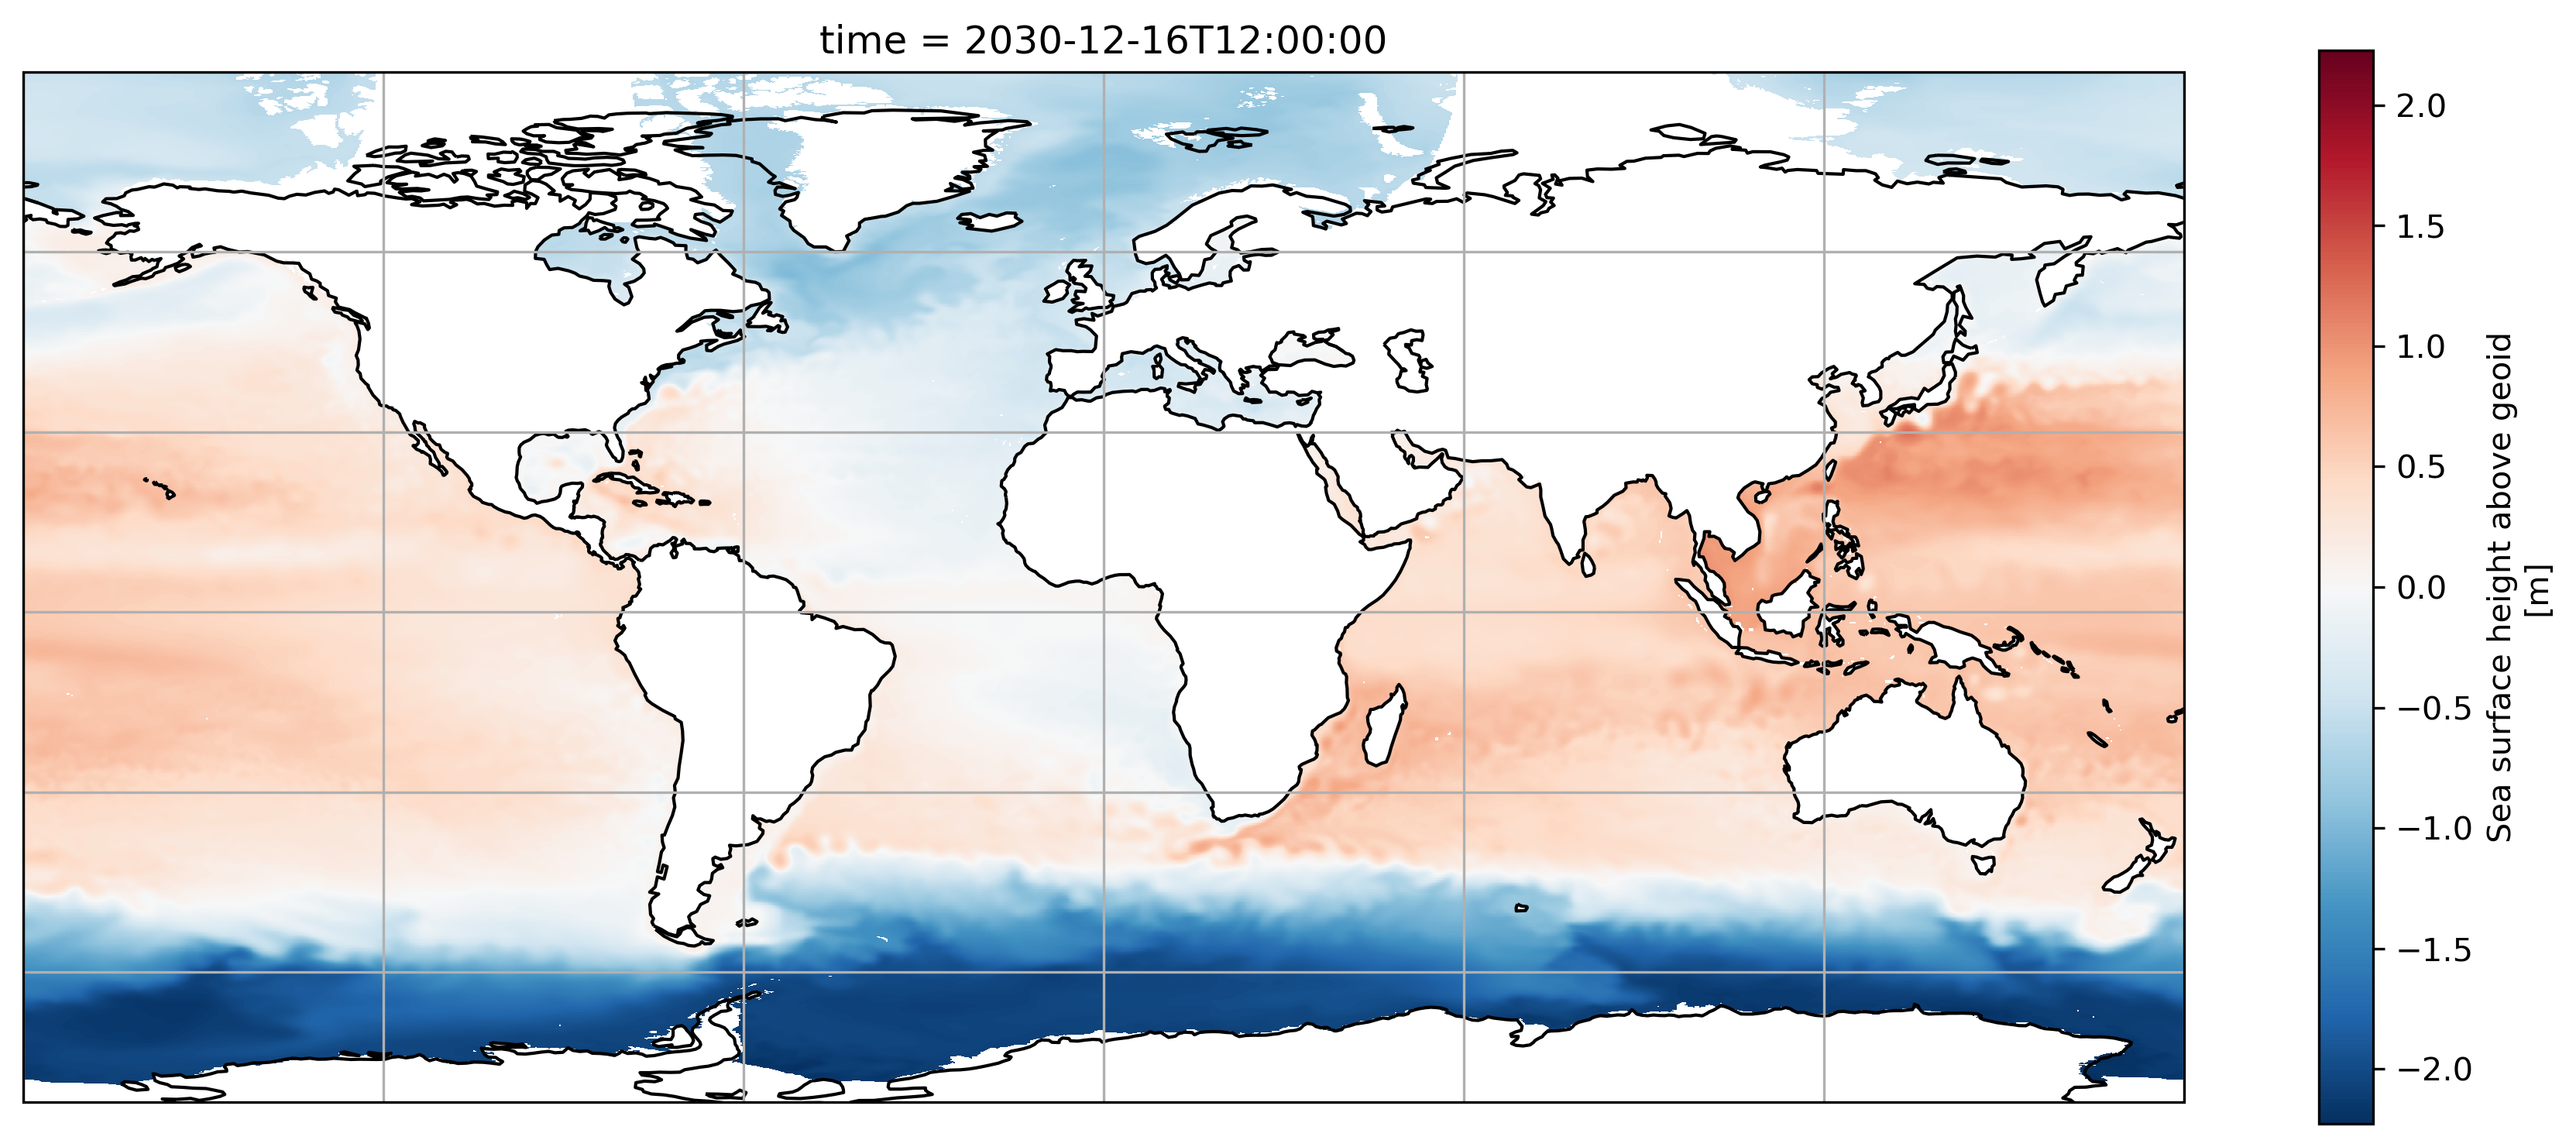

In [11]:
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(15,6), subplot_kw=dict(projection=proj))

zos["zos"].isel(time=-1).plot(ax=ax)
ax.coastlines()
_ = ax.gridlines()

#### Fixing the plot axes

Notice that the white land-masked regions are distorted away from the coastlines in the Arctic in the above plot. This is because a tripolar grid is used, so the grid lines are not zonal and meridional north of 65N, and consequently the nominal 1D coordinates `xh` and `yh` are incorrect. To fix this we need to use 2d coordinates `geolon` and `geolat`.

We can get these coorindates from the intake-esm datastore. However, note that `geolon` and `geolat` contain NaNs in regions where processors were masked over land. Below we replace these NaNs with zeros so that the coordinates can be used for plotting.

In [24]:
coords = datastore.search(variable=["geolat", "geolon"]).to_dask(
    preprocess=lambda ds: ds.set_coords(["geolat", "geolon"])
).compute()
coords = coords.fillna(0.0)

zos = zos.assign_coords(coords)

Now try that plot again, this time using `geolon` and `geolat`.

ValueError: x must be one of None, 'time', 'xh', 'yh'. Received 'geolon' instead.

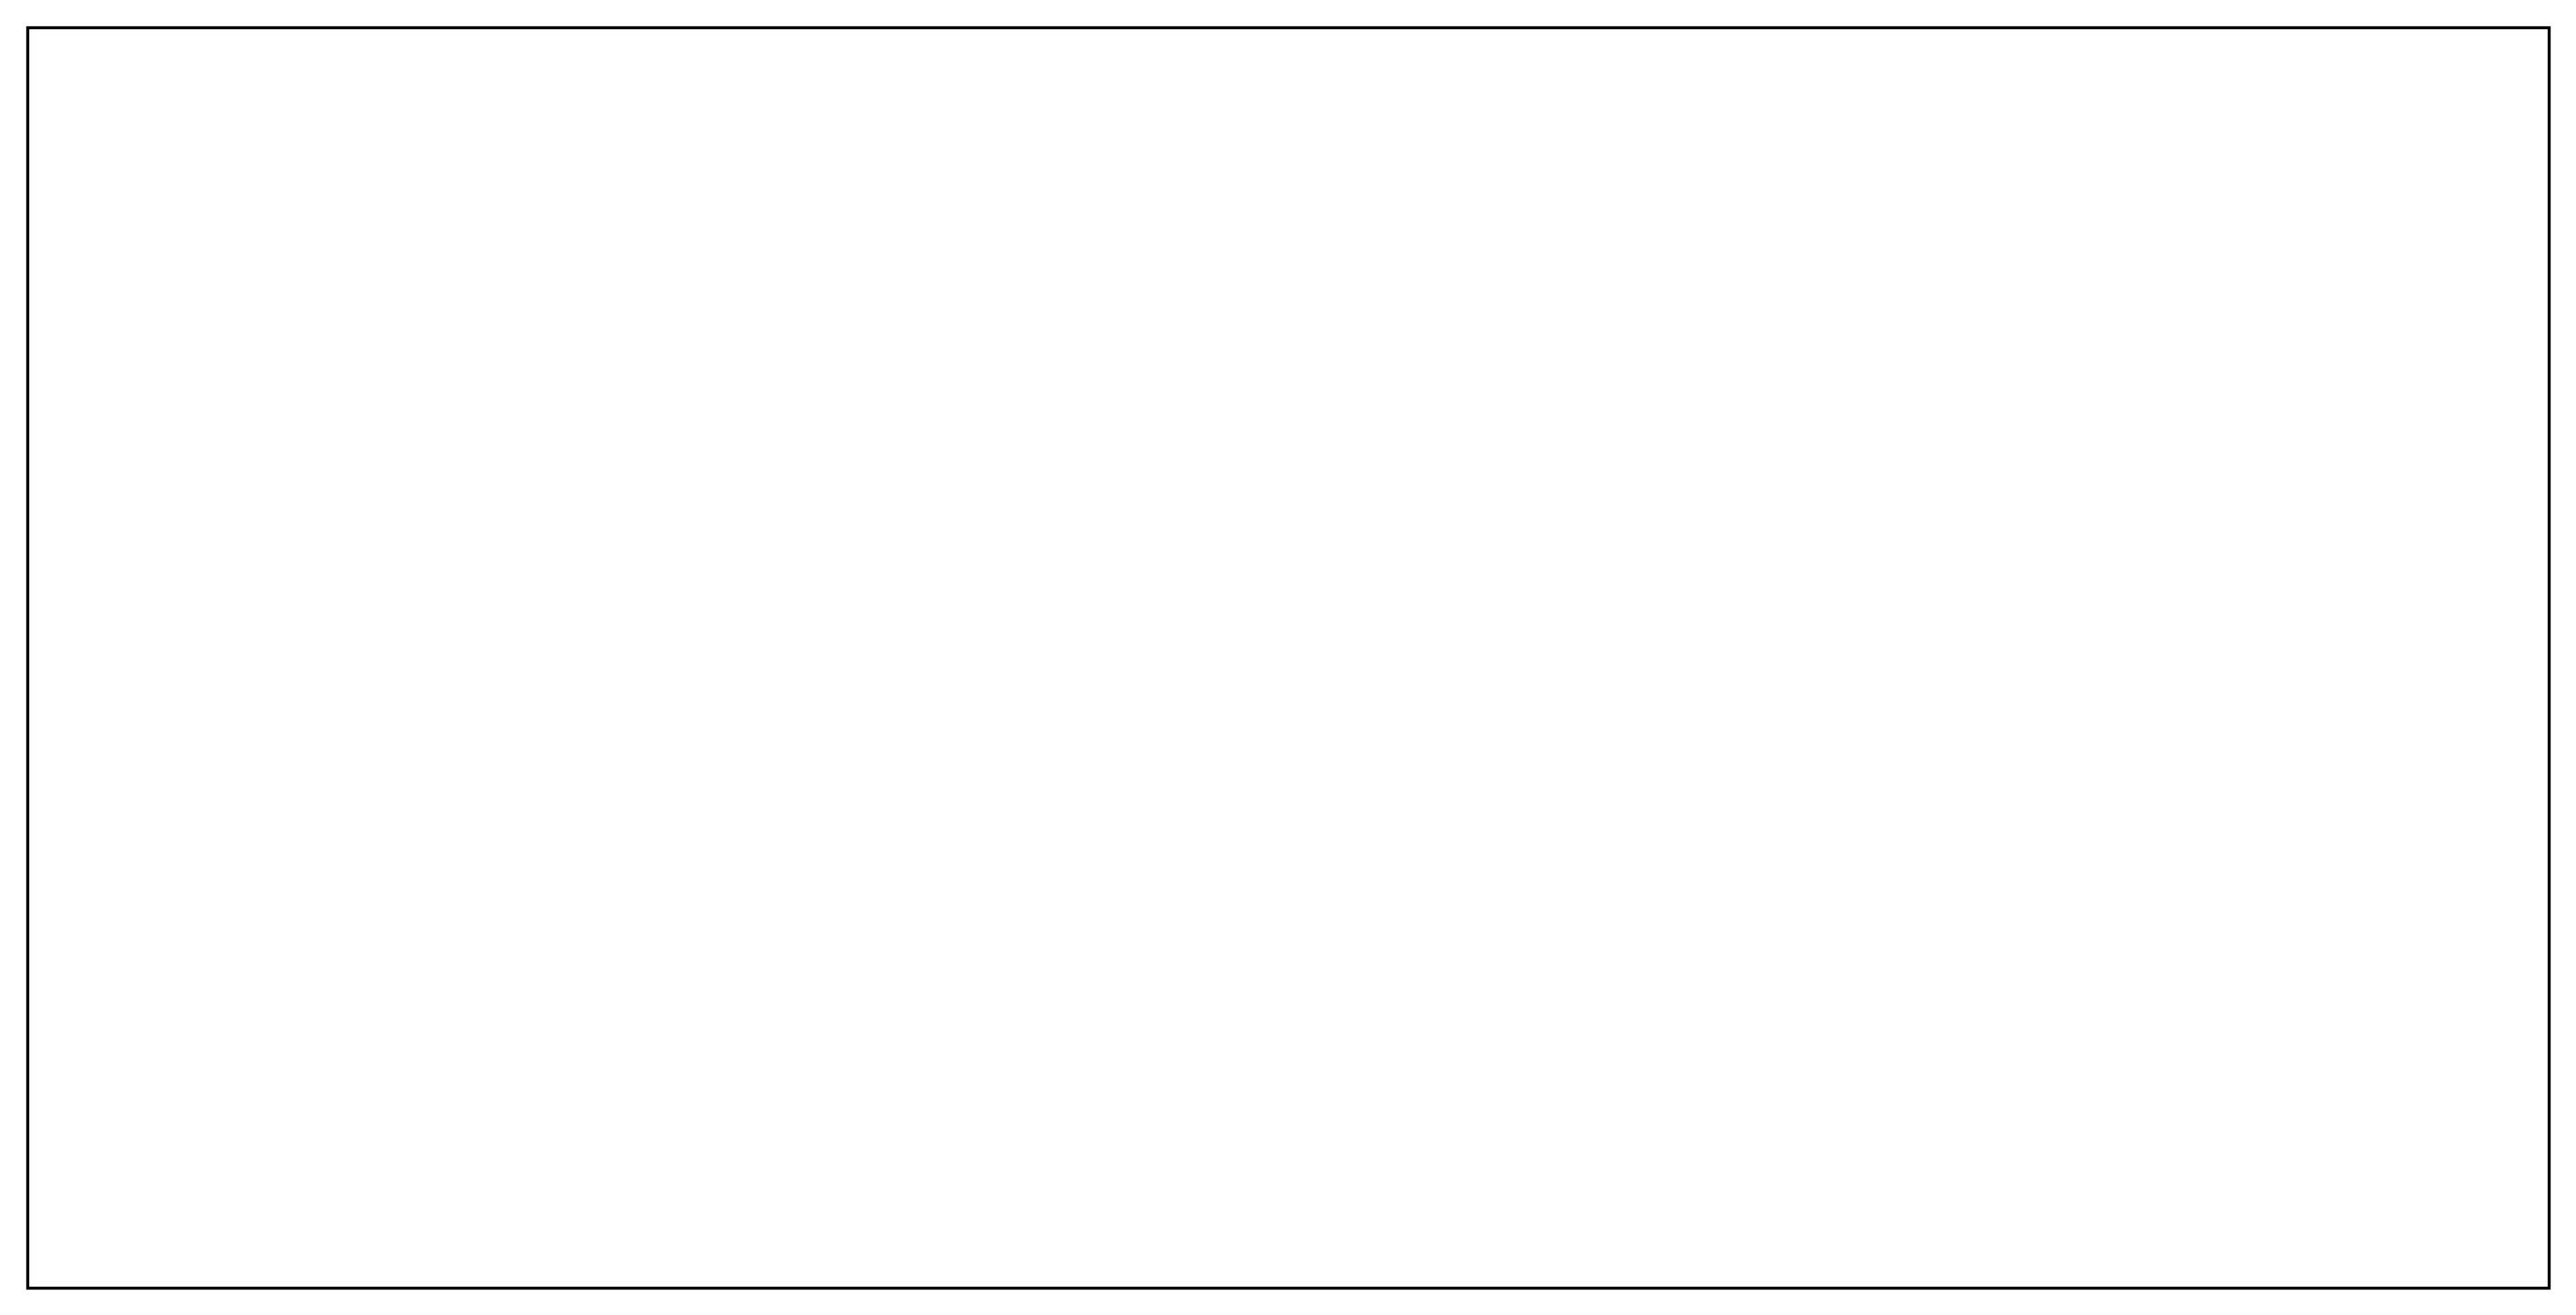

In [25]:
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(15,6), subplot_kw=dict(projection=proj))

zos["zos"].isel(time=-1).plot(ax=ax, x="geolon", y="geolat")

ax.coastlines()
_ = ax.gridlines()
plt.savefig(plotfolder+'exampleout.png')

In [11]:
client.close()